# Cahoy 2010 vs Aurora PICASO comparison

This notebook compares Aurora PICASO NetCDF spectra against the Cahoy et al. (2010) reference spectra and reports per-case error metrics.

It is designed to work while the production run is still in progress:
- if `AVAILABLE_ONLY = True`, it compares only NetCDF files that already exist;
- if `AVAILABLE_ONLY = False`, it also reports missing/failing cases.

Workflow in this notebook:
1. Load paths, imports, and comparison utilities.
2. Compare all available manifest rows and build a metrics table.
3. Save `cahoy_compare_metrics.csv` and `cahoy_compare_summary.json`.
4. Plot the highest-RMSE cases for quick inspection.
5. Interactively select any individual case for deeper comparison.

Before running, make sure the environment and reference spectra are available:

```bash
source env/activate_aurora_picaso4_job.sh
bash roadrunner_egp/aurora_subneptune_grid/scripts/install_cahoy2010_reference.sh
```

In [68]:
import inspect
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in [cwd, *cwd.parents]
     if (p / "roadrunner_egp" / "aurora_subneptune_grid" / "src" / "aurora_grid").exists()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing roadrunner_egp/aurora_subneptune_grid/src/aurora_grid")

GRID_ROOT = REPO_ROOT / "roadrunner_egp" / "aurora_subneptune_grid"
MODEL = "aurora_cahoy2010_replication_v0"
MANIFEST = GRID_ROOT / "manifests" / f"{MODEL}_manifest.csv"
NC_ROOT = GRID_ROOT / "outputs" / MODEL / "nc"
COMPARE_ROOT = GRID_ROOT / "outputs" / MODEL / "cahoy_compare"
PLOT_ROOT = COMPARE_ROOT / "plots"

for extra in (GRID_ROOT / "src", REPO_ROOT / "roadrunner_egp"):
    s = str(extra)
    if s not in sys.path:
        sys.path.insert(0, s)

from aurora_grid.cahoy_compare import (
    compare_manifest_outputs,
    compare_nc_to_cahoy,
    ensure_reference_installed,
    metrics_to_records,
)

COMPARE_SUPPORTS_EXISTING_ONLY = "existing_only" in inspect.signature(compare_manifest_outputs).parameters

REFERENCE_ROOT = ensure_reference_installed()
COMPARE_ROOT.mkdir(parents=True, exist_ok=True)
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

# Keep this True while the HPC array is still generating spectra.
AVAILABLE_ONLY = True
N_MANIFEST_ROWS = len(pd.read_csv(MANIFEST, usecols=["run_index"]))
N_EXISTING_NC = len(list(NC_ROOT.glob("run_*.nc")))

print("REPO_ROOT:", REPO_ROOT)
print("GRID_ROOT:", GRID_ROOT)
print("Reference:", REFERENCE_ROOT)
print("NC dir:", NC_ROOT)
print("compare_manifest_outputs supports existing_only:", COMPARE_SUPPORTS_EXISTING_ONLY)
print(f"existing NetCDF files: {N_EXISTING_NC} / {N_MANIFEST_ROWS}")

REPO_ROOT: /home/u11/danielxinhuang/Documents/aurora
GRID_ROOT: /home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid
Reference: /home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/data/cahoy2010_reference/Cahoy_et_al_2010_Albedo_Spectra/albedo_spectra
NC dir: /home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/nc
compare_manifest_outputs supports existing_only: False
existing NetCDF files: 299 / 304


## Notes on outputs

- `df` contains one row per attempted case and a `status` column.
- `df_ok` includes only successful comparisons (`status == "ok"`).
- `results` stores the full tuple `(metrics, arrays, error)` used by plotting cells.
- `ok` is the list of successful entries and is reused by the interactive selector at the end.

In [69]:
compare_kwargs = {"reference_root": REFERENCE_ROOT}
if COMPARE_SUPPORTS_EXISTING_ONLY:
    compare_kwargs["existing_only"] = AVAILABLE_ONLY

results = compare_manifest_outputs(
    MANIFEST,
    NC_ROOT,
    **compare_kwargs,
)

# Backward compatibility for older aurora_grid versions that do not expose
# `existing_only` in compare_manifest_outputs.
if AVAILABLE_ONLY and not COMPARE_SUPPORTS_EXISTING_ONLY:
    results = [item for item in results if item[2] != "missing_nc"]

records = metrics_to_records(results)
df = pd.DataFrame(records)
if df.empty:
    df_ok = df.copy()
    print(f"No NetCDF files found in {NC_ROOT}")
else:
    df_ok = df[df["status"] == "ok"].copy()
    print(f"compared: {len(df_ok)} available files / {N_MANIFEST_ROWS} manifest rows")
    print(df["status"].value_counts(dropna=False).to_string())
if not df_ok.empty:
    display(df_ok.sort_values("rmse", ascending=False).head(10))
elif not df.empty:
    display(df.head())

compared: 299 available files / 304 manifest rows
status
ok    299


,cahoy_reference_name,run_index,output_nc,phase_deg,n_points,rmse,mae,max_abs_diff,mean_cahoy_albedo,mean_aurora_albedo,relative_rmse,pearson_r,status
242,Neptune_30x_2AU_0deg.dat,247,/home/u11/danielxinhuang/Documents/aurora/road...,0.0,790,0.175861,0.134919,0.475444,0.513873,0.445455,0.342226,0.822388,ok
243,Neptune_30x_2AU_10deg.dat,248,/home/u11/danielxinhuang/Documents/aurora/road...,10.0,790,0.174774,0.134217,0.466816,0.503408,0.430339,0.347182,0.821976,ok
244,Neptune_30x_2AU_20deg.dat,249,/home/u11/danielxinhuang/Documents/aurora/road...,20.0,790,0.171267,0.132755,0.443115,0.473264,0.393217,0.361885,0.822508,ok
130,Jupiter_3x_10AU_0deg.dat,133,/home/u11/danielxinhuang/Documents/aurora/road...,0.0,790,0.167728,0.156577,0.226564,0.278460,0.404427,0.602340,0.800016,ok
245,Neptune_30x_2AU_30deg.dat,250,/home/u11/danielxinhuang/Documents/aurora/road...,30.0,790,0.162881,0.128057,0.408685,0.433117,0.346794,0.376068,0.825547,ok
131,Jupiter_3x_10AU_10deg.dat,134,/home/u11/danielxinhuang/Documents/aurora/road...,10.0,790,0.162273,0.151463,0.219501,0.269426,0.390940,0.602290,0.802575,ok
246,Neptune_30x_2AU_40deg.dat,251,/home/u11/danielxinhuang/Documents/aurora/road...,40.0,790,0.150059,0.120432,0.365373,0.383682,0.298917,0.391103,0.828905,ok
132,Jupiter_3x_10AU_20deg.dat,135,/home/u11/danielxinhuang/Documents/aurora/road...,20.0,790,0.147769,0.138144,0.200395,0.247918,0.357066,0.596039,0.807415,ok
112,Jupiter_3x_5AU_0deg.dat,114,/home/u11/danielxinhuang/Documents/aurora/road...,0.0,790,0.139540,0.128925,0.272168,0.477439,0.556486,0.292268,0.892502,ok
113,Jupiter_3x_5AU_10deg.dat,115,/home/u11/danielxinhuang/Documents/aurora/road...,10.0,790,0.134309,0.123852,0.267730,0.464261,0.539042,0.289296,0.893219,ok


In [70]:
metrics_path = COMPARE_ROOT / "cahoy_compare_metrics.csv"
if not df.empty:
    df.to_csv(metrics_path, index=False)
status_counts = df["status"].value_counts().to_dict() if "status" in df else {}
summary = {
    "manifest": str(MANIFEST),
    "nc_root": str(NC_ROOT),
    "available_only": AVAILABLE_ONLY,
    "n_manifest_rows": int(N_MANIFEST_ROWS),
    "n_existing_nc": int(N_EXISTING_NC),
    "n_rows_checked": int(len(df)),
    "n_compared": int(status_counts.get("ok", 0)),
    "n_missing_nc": int(status_counts.get("missing_nc", 0)),
    "n_failed": int(sum(count for status, count in status_counts.items() if status not in ["ok", "missing_nc"])),
    "median_rmse": float(df_ok["rmse"].median()) if not df_ok.empty else None,
    "max_rmse": float(df_ok["rmse"].max()) if not df_ok.empty else None,
}
if not df_ok.empty:
    summary["worst_case"] = str(df_ok.sort_values("rmse", ascending=False).iloc[0]["cahoy_reference_name"])
(COMPARE_ROOT / "cahoy_compare_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
if not df.empty:
    print(f"wrote {metrics_path}")

{
  "manifest": "/home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/manifests/aurora_cahoy2010_replication_v0_manifest.csv",
  "nc_root": "/home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/nc",
  "available_only": true,
  "n_manifest_rows": 304,
  "n_existing_nc": 299,
  "n_rows_checked": 299,
  "n_compared": 299,
  "n_missing_nc": 0,
  "n_failed": 0,
  "median_rmse": 0.02707202246662318,
  "max_rmse": 0.17586067178891257,
  "worst_case": "Neptune_30x_2AU_0deg.dat"
}
wrote /home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/cahoy_compare/cahoy_compare_metrics.csv


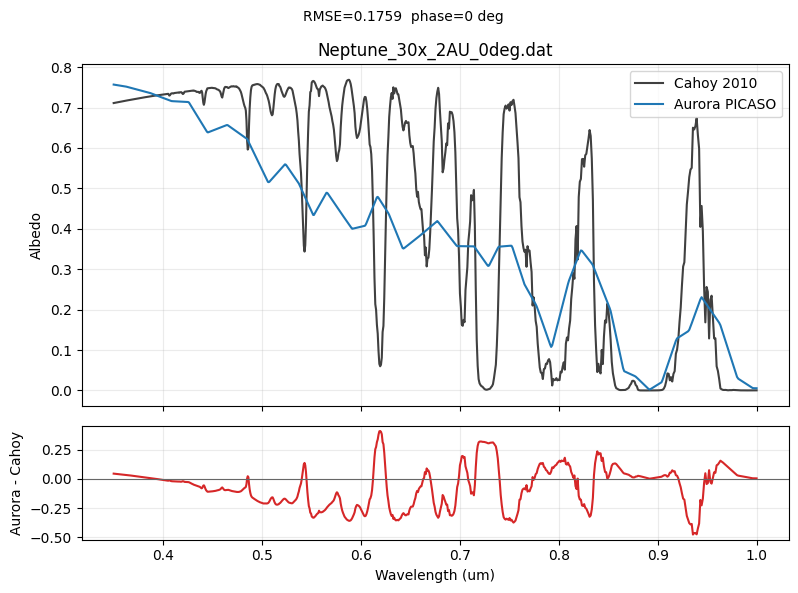

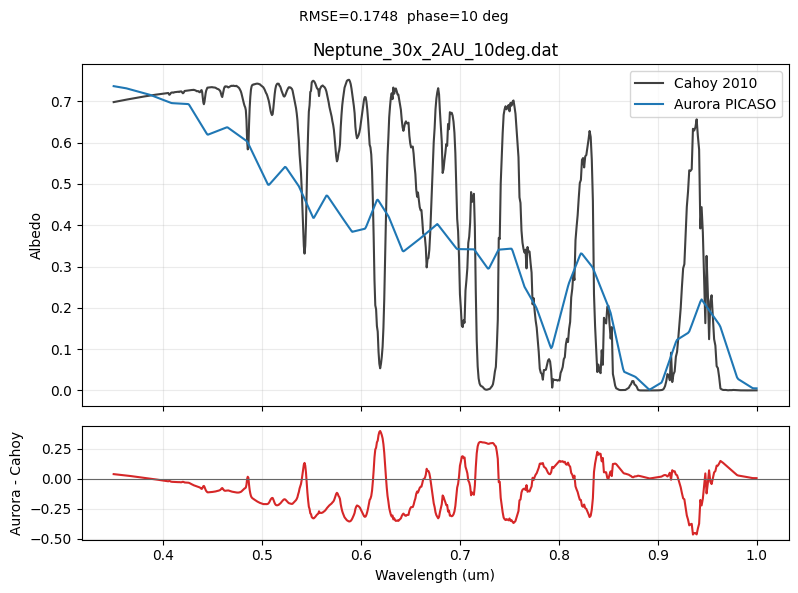

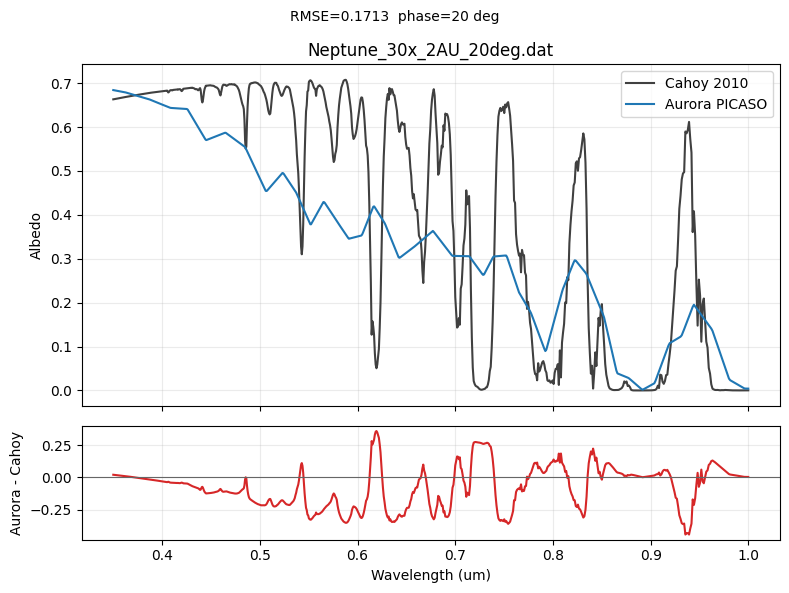

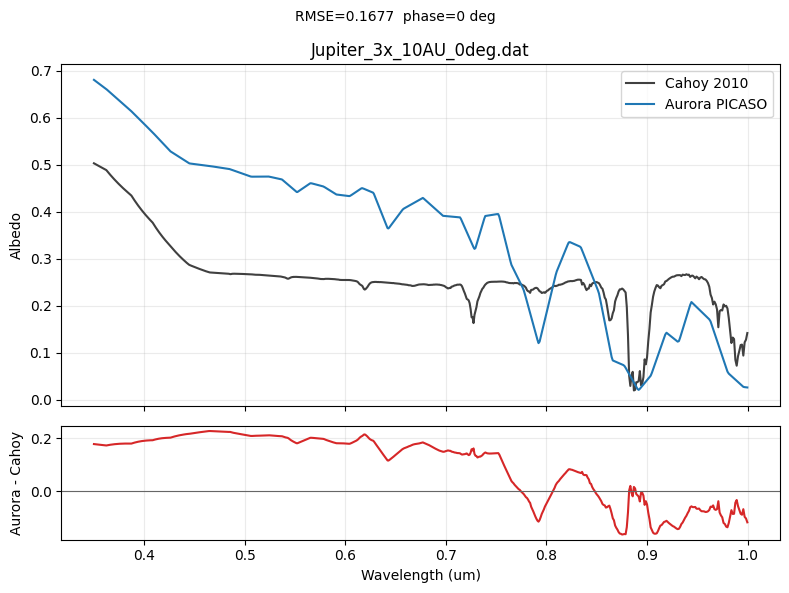

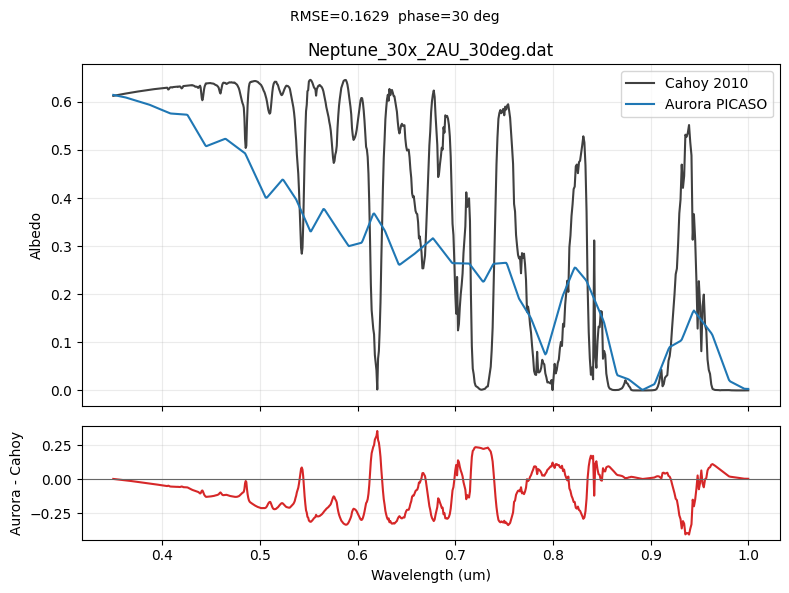

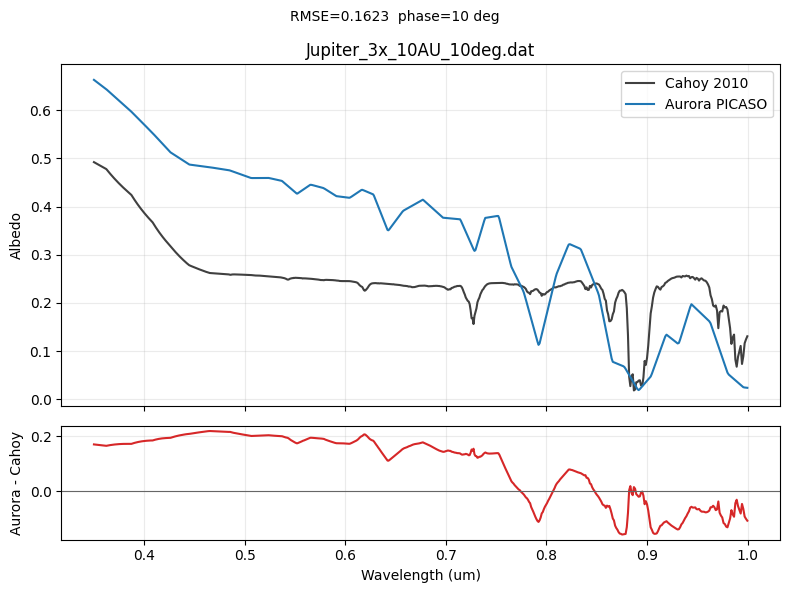

wrote 6 plots to /home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/cahoy_compare/plots


In [71]:
def plot_pair(metrics, arrays, out_path=None):
    wave = arrays["wavelength_um"]
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    axes[0].plot(wave, arrays["cahoy_albedo"], label="Cahoy 2010", color="0.25")
    axes[0].plot(wave, arrays["aurora_albedo"], label="Aurora PICASO", color="C0")
    axes[0].set_ylabel("Albedo")
    axes[0].set_title(metrics.cahoy_reference_name)
    axes[0].legend()
    axes[0].grid(alpha=0.25)
    axes[1].plot(wave, arrays["residual"], color="C3")
    axes[1].axhline(0, color="0.4", lw=0.8)
    axes[1].set_xlabel("Wavelength (um)")
    axes[1].set_ylabel("Aurora - Cahoy")
    axes[1].grid(alpha=0.25)
    fig.suptitle(f"RMSE={metrics.rmse:.4f}  phase={metrics.phase_deg:.0f} deg", fontsize=10)
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
    return fig


ok = [item for item in results if item[2] is None]
for metrics, arrays, _ in sorted(ok, key=lambda item: item[0].rmse, reverse=True)[:6]:
    stem = metrics.cahoy_reference_name.replace(".dat", "")
    plot_pair(metrics, arrays, PLOT_ROOT / f"{stem}.png")
    plt.show()
print(f"wrote {min(len(ok), 6)} plots to {PLOT_ROOT}")

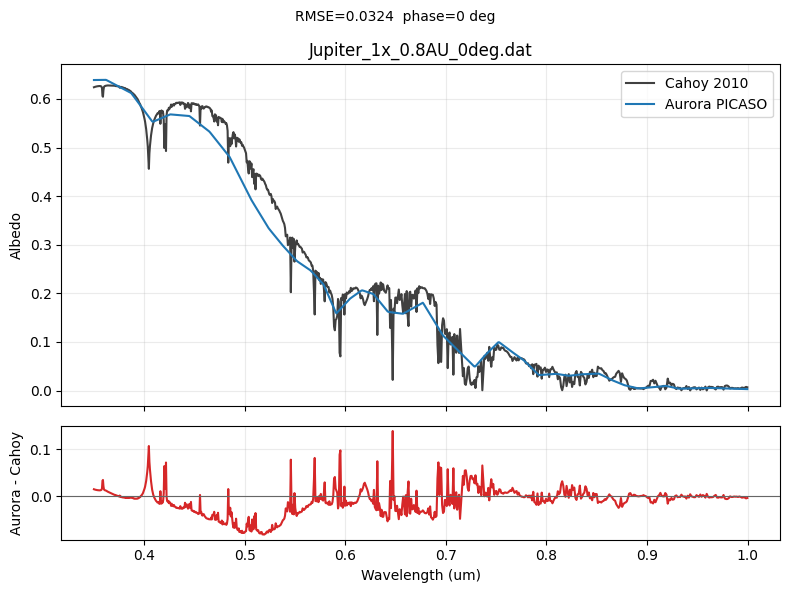

In [72]:
# Pick one case to inspect interactively. If CASE_NAME is not available yet,
# show the worst currently compared case instead.
CASE_NAME = "Jupiter_1x_0.8AU_0deg.dat"
case = next((item for item in ok if item[0].cahoy_reference_name == CASE_NAME), None)
if case is None and ok:
    case = max(ok, key=lambda item: item[0].rmse)
    print(f"{CASE_NAME} is not available yet; showing {case[0].cahoy_reference_name} instead.")

if case is not None:
    metrics, arrays, _ = case
    plot_pair(metrics, arrays)
    plt.show()
else:
    print(f"No comparable NetCDF files found in {NC_ROOT}")

{
  "case": "Jupiter_1x_0.8AU_0deg.dat",
  "run_index": 0,
  "phase_deg": 0.0,
  "rmse": 0.0323749298046821,
  "mae": 0.02318640329592969,
  "max_abs_diff": 0.1387609062679625,
  "pearson_r": 0.9920922263967833
}


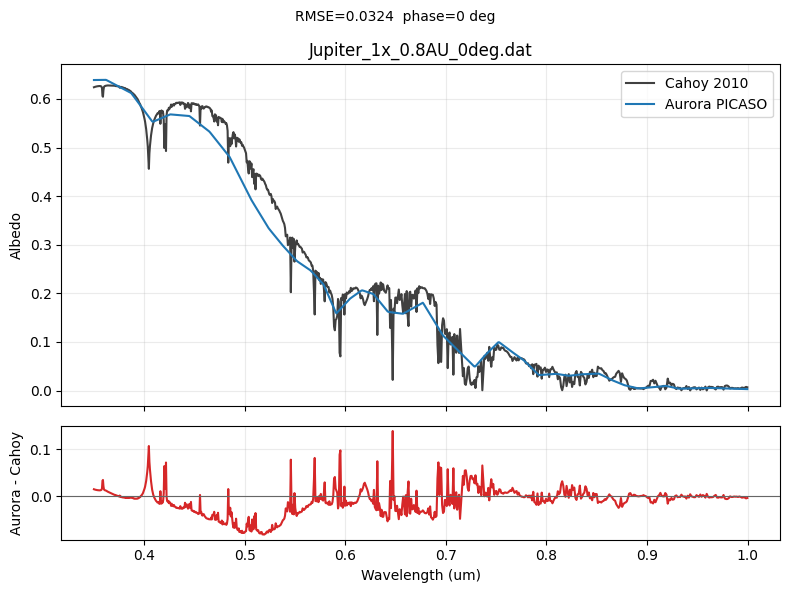

In [73]:
def compare_case(case_name=None, match_mode="exact", show_plot=True):
    """Select any available case and plot Aurora vs Cahoy comparison.

    Parameters
    ----------
    case_name : str | None
        Case file name, e.g. "Jupiter_1x_0.8AU_0deg.dat".
        If None, this selects the current worst-RMSE case.
    match_mode : str
        One of: "exact", "contains", "startswith".
    show_plot : bool
        If True, display the generated figure.

    Returns
    -------
    tuple | None
        (metrics, arrays, error) for the selected case, or None if not found.
    """
    if not ok:
        print(f"No successful comparisons available yet in {NC_ROOT}")
        return None

    valid_modes = {"exact", "contains", "startswith"}
    if match_mode not in valid_modes:
        raise ValueError(f"match_mode must be one of {sorted(valid_modes)}")

    if case_name is None:
        chosen = max(ok, key=lambda item: item[0].rmse)
        print(f"No case_name provided; using worst case: {chosen[0].cahoy_reference_name}")
    else:
        needle = case_name.lower()

        def _is_match(name):
            hay = name.lower()
            if match_mode == "exact":
                return hay == needle
            if match_mode == "contains":
                return needle in hay
            return hay.startswith(needle)

        matches = [item for item in ok if _is_match(item[0].cahoy_reference_name)]
        if not matches:
            print(f"No matches for {case_name!r} (mode={match_mode}).")
            print("Tip: use match_mode='contains' for partial names.")
            print("First 12 available cases:")
            for name in sorted(item[0].cahoy_reference_name for item in ok)[:12]:
                print(f"  - {name}")
            return None

        chosen = max(matches, key=lambda item: item[0].rmse)
        if len(matches) > 1:
            print(f"{len(matches)} matches found; showing highest-RMSE match: {chosen[0].cahoy_reference_name}")

    metrics, arrays, _ = chosen
    print(
        json.dumps(
            {
                "case": metrics.cahoy_reference_name,
                "run_index": int(metrics.run_index),
                "phase_deg": float(metrics.phase_deg),
                "rmse": float(metrics.rmse),
                "mae": float(metrics.mae),
                "max_abs_diff": float(metrics.max_abs_diff),
                "pearson_r": float(metrics.pearson_r),
            },
            indent=2,
        )
    )
    fig = plot_pair(metrics, arrays)
    if show_plot:
        plt.show()
    return chosen


# Example usage:
# compare_case("Jupiter_1x_0.8AU_0deg.dat", match_mode="exact")
# compare_case("Jupiter_1x", match_mode="contains")
_ = compare_case("Jupiter_1x_0.8AU_0deg.dat")

{
  "case": "Neptune_10x_2AU_180deg.dat",
  "run_index": 189,
  "phase_deg": 180.0,
  "rmse": 2.429263892685391e-14,
  "mae": 2.1271457772086097e-14,
  "max_abs_diff": 3.113910354150219e-14,
  "pearson_r": NaN
}
all cahoy zero: True
max |residual - aurora|: 0.0
residual min/max: 1.18703389980396e-16 3.113910354150219e-14


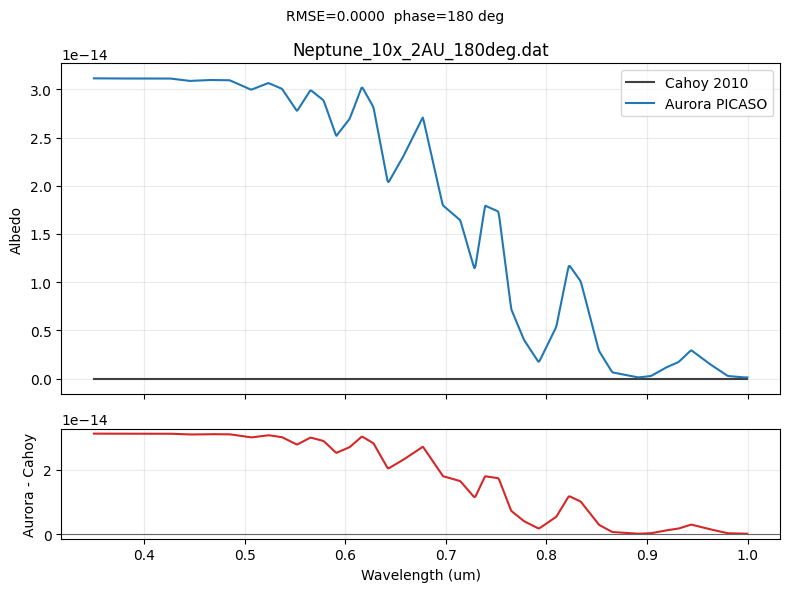

In [74]:
metrics, arrays, _ = compare_case("Neptune_10x_2AU_180deg.dat", show_plot=False)
print("all cahoy zero:", (arrays["cahoy_albedo"] == 0).all())
print("max |residual - aurora|:", abs(arrays["residual"] - arrays["aurora_albedo"]).max())
print("residual min/max:", arrays["residual"].min(), arrays["residual"].max())

{
  "case": "Neptune_10x_2AU_180deg.dat",
  "run_index": 189,
  "phase_deg": 180.0,
  "rmse": 2.429263892685391e-14,
  "mae": 2.1271457772086097e-14,
  "max_abs_diff": 3.113910354150219e-14,
  "pearson_r": NaN
}


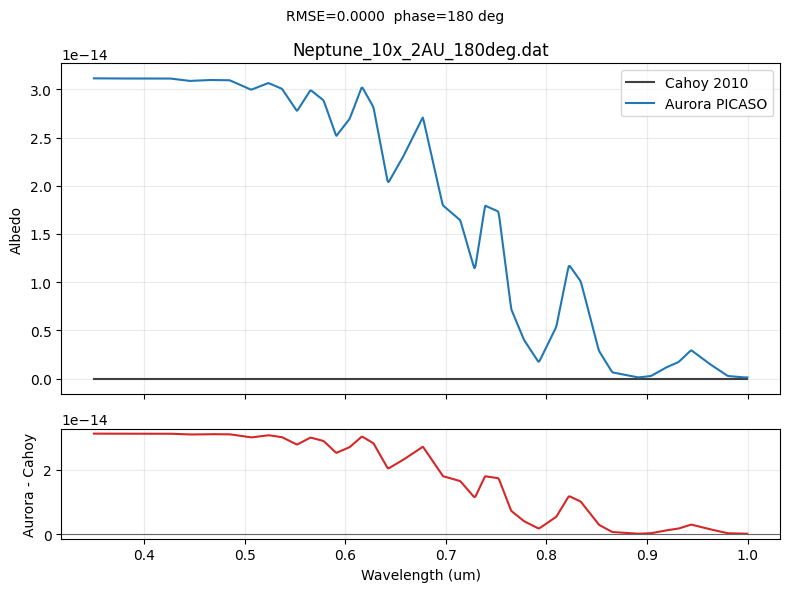

(CahoyCompareMetrics(cahoy_reference_name='Neptune_10x_2AU_180deg.dat', run_index=189, output_nc='/home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/nc/run_000189.nc', phase_deg=180.0, n_points=790, rmse=2.429263892685391e-14, mae=2.1271457772086097e-14, max_abs_diff=3.113910354150219e-14, mean_cahoy_albedo=0.0, mean_aurora_albedo=2.1271457772086097e-14, relative_rmse=2.429263892685391e-08, pearson_r=nan),
 {'wavelength_um': array([0.35    , 0.350466, 0.350932, 0.3514  , 0.351867, 0.352336,
         0.352805, 0.353274, 0.353745, 0.354216, 0.354687, 0.355159,
         0.355632, 0.356105, 0.35658 , 0.357054, 0.35753 , 0.358005,
         0.358482, 0.358959, 0.359437, 0.359916, 0.360395, 0.360874,
         0.361355, 0.361836, 0.362317, 0.3628  , 0.363283, 0.363766,
         0.364251, 0.364735, 0.365221, 0.365707, 0.366194, 0.366681,
         0.36717 , 0.367658, 0.368148, 0.368638, 0.369129, 0.36962 ,
         0.370112, 0.

In [75]:
compare_case("Neptune_10x_2AU_180deg.dat", match_mode="exact")


{
  "case": "Jupiter_3x_10AU_0deg.dat",
  "run_index": 133,
  "phase_deg": 0.0,
  "rmse": 0.16772773913187425,
  "mae": 0.15657737978883052,
  "max_abs_diff": 0.2265641582115243,
  "pearson_r": 0.8000162565932116
}


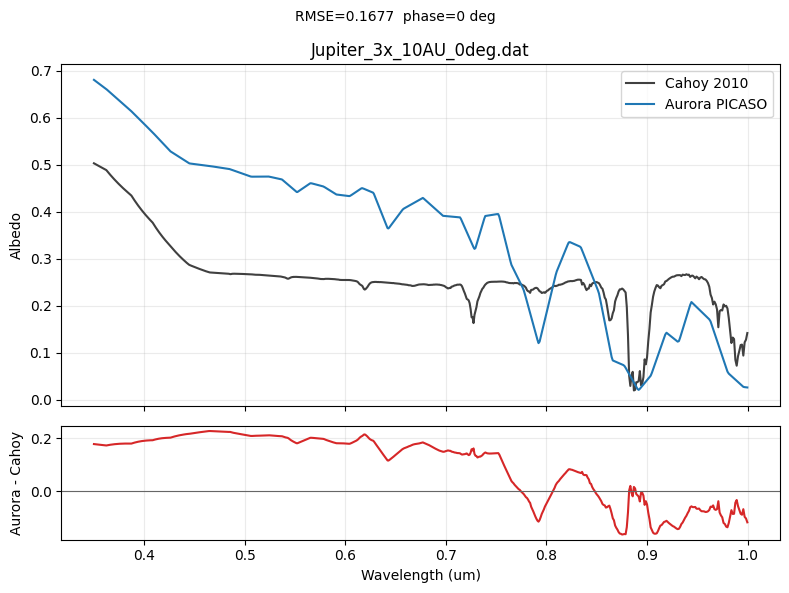

(CahoyCompareMetrics(cahoy_reference_name='Jupiter_3x_10AU_0deg.dat', run_index=133, output_nc='/home/u11/danielxinhuang/Documents/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/nc/run_000133.nc', phase_deg=0.0, n_points=790, rmse=0.16772773913187425, mae=0.15657737978883052, max_abs_diff=0.2265641582115243, mean_cahoy_albedo=0.2784602174683544, mean_aurora_albedo=0.4044274376041988, relative_rmse=0.6023400421675518, pearson_r=0.8000162565932116),
 {'wavelength_um': array([0.35    , 0.350466, 0.350932, 0.3514  , 0.351867, 0.352336,
         0.352805, 0.353274, 0.353745, 0.354216, 0.354687, 0.355159,
         0.355632, 0.356105, 0.35658 , 0.357054, 0.35753 , 0.358005,
         0.358482, 0.358959, 0.359437, 0.359916, 0.360395, 0.360874,
         0.361355, 0.361836, 0.362317, 0.3628  , 0.363283, 0.363766,
         0.364251, 0.364735, 0.365221, 0.365707, 0.366194, 0.366681,
         0.36717 , 0.367658, 0.368148, 0.368638, 0.369129, 0.36962 ,
         0

In [76]:
compare_case("Jupiter_3x_10AU_0deg.dat", match_mode="exact")

## RMSE traffic-light diagnostics

Use this section to quickly identify where mismatches concentrate.

- **good**: RMSE < 0.05
- **watch**: 0.05 <= RMSE < 0.10
- **alert**: RMSE >= 0.10

The table views below highlight the worst individual cases and grouped hot spots by planet/metallicity/orbital distance.

In [77]:
def rmse_traffic_light_report(df_ok, warn_threshold=0.05, alert_threshold=0.10, top_n=12):
    """Summarize RMSE quality bands and hotspot groupings."""
    if df_ok.empty:
        print("No successful comparisons available yet.")
        return None

    work = df_ok.copy()
    work["rmse_band"] = pd.cut(
        work["rmse"],
        bins=[-float("inf"), warn_threshold, alert_threshold, float("inf")],
        labels=["good", "watch", "alert"],
        right=False,
    )

    name_parts = (
        work["cahoy_reference_name"]
        .str.replace(".dat", "", regex=False)
        .str.extract(r"(?P<planet>[^_]+)_(?P<metallicity>[^_]+)_(?P<orbital_distance>[^_]+)_(?P<phase_label>[^_]+)")
    )
    work = pd.concat([work, name_parts], axis=1)

    counts = work["rmse_band"].value_counts().reindex(["good", "watch", "alert"], fill_value=0)
    total = len(work)
    print(f"RMSE thresholds: good < {warn_threshold:.3f}, watch < {alert_threshold:.3f}, alert >= {alert_threshold:.3f}")
    for band in ["good", "watch", "alert"]:
        n = int(counts[band])
        pct = 100.0 * n / total
        print(f"  {band:>5}: {n:3d} ({pct:5.1f}%)")

    alert_cases = work[work["rmse"] >= alert_threshold].sort_values("rmse", ascending=False)
    if alert_cases.empty:
        print("\nNo alert-level cases found.")
        return {"work": work, "alerts": alert_cases, "alert_groups": pd.DataFrame()}

    alert_groups = (
        alert_cases.groupby(["planet", "metallicity", "orbital_distance"], dropna=False)
        .agg(
            n_alert=("rmse", "size"),
            median_rmse=("rmse", "median"),
            max_rmse=("rmse", "max"),
        )
        .sort_values(["n_alert", "max_rmse"], ascending=[False, False])
    )

    print("\nTop alert cases:")
    display(
        alert_cases[
            [
                "cahoy_reference_name",
                "phase_deg",
                "rmse",
                "mae",
                "max_abs_diff",
                "pearson_r",
            ]
        ].head(top_n)
    )

    print("Alert hotspots by (planet, metallicity, orbital_distance):")
    display(alert_groups.head(top_n))

    print("Alert counts by phase_deg:")
    display(alert_cases.groupby("phase_deg").size().rename("n_alert").to_frame())

    return {
        "work": work,
        "alerts": alert_cases,
        "alert_groups": alert_groups,
    }


traffic = rmse_traffic_light_report(df_ok, warn_threshold=0.05, alert_threshold=0.10, top_n=12)

RMSE thresholds: good < 0.050, watch < 0.100, alert >= 0.100
   good: 210 ( 70.2%)
  watch:  62 ( 20.7%)
  alert:  27 (  9.0%)

Top alert cases:


,cahoy_reference_name,phase_deg,rmse,mae,max_abs_diff,pearson_r
242,Neptune_30x_2AU_0deg.dat,0.0,0.175861,0.134919,0.475444,0.822388
243,Neptune_30x_2AU_10deg.dat,10.0,0.174774,0.134217,0.466816,0.821976
244,Neptune_30x_2AU_20deg.dat,20.0,0.171267,0.132755,0.443115,0.822508
130,Jupiter_3x_10AU_0deg.dat,0.0,0.167728,0.156577,0.226564,0.800016
245,Neptune_30x_2AU_30deg.dat,30.0,0.162881,0.128057,0.408685,0.825547
131,Jupiter_3x_10AU_10deg.dat,10.0,0.162273,0.151463,0.219501,0.802575
246,Neptune_30x_2AU_40deg.dat,40.0,0.150059,0.120432,0.365373,0.828905
132,Jupiter_3x_10AU_20deg.dat,20.0,0.147769,0.138144,0.200395,0.807415
112,Jupiter_3x_5AU_0deg.dat,0.0,0.139540,0.128925,0.272168,0.892502
113,Jupiter_3x_5AU_10deg.dat,10.0,0.134309,0.123852,0.267730,0.893219


Alert hotspots by (planet, metallicity, orbital_distance):


n_alert  median_rmse  max_rmse
planet  metallicity orbital_distance                                
Neptune 30x         2AU                     7     0.162881  0.175861
Jupiter 3x          2AU                     6     0.129207  0.132971
                    10AU                    5     0.147769  0.167728
Neptune 10x         2AU                     5     0.120747  0.129361
Jupiter 3x          5AU                     4     0.127982  0.139540

Alert counts by phase_deg:


,n_alert
phase_deg,
0.0,5
10.0,5
20.0,5
30.0,5
40.0,4
50.0,2
60.0,1
